In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from common import get_triads,get_G
%config InlineBackend.figure_format='retina'

# Setup

In [3]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)
rho=lambda x: 1.62125753*(x**(-7/3))
rho_con=lambda x: 5.25*(x**-3)
rho2=lambda x: 0.85*x**(-7/3)

k,p,q,kmag,pmag,qmag,Gcosrho,Gcosrho_dir=get_G(return_triads=True,kmax=kmax,kmin=kmin,rho=rho)
_,Gcosrho_dir_con=get_G(return_triads=False,kmax=kmax,kmin=kmin,rho=rho_con)

# k,p,q,kmag,pmag,qmag=get_triads(duplicates=True,kmax=kmax,kmin=kmin)
# # rhok=rho2(kmag);rhop=rho2(pmag);rhoq=rho2(qmag);
# # rhok[order(k)%2==1]=rho_con(kmag[order(k)%2==1])
# # rhop[order(p)%2==1]=rho_con(pmag[order(p)%2==1])
# # rhoq[order(q)%2==1]=rho_con(qmag[order(q)%2==1])
# rhok=rho_con(kmag);rhop=rho_con(pmag);rhoq=rho_con(qmag);
# K=((qmag**2-pmag**2)*kmag**-2*(rhop*rhoq)**2)+((pmag**2-kmag**2)*qmag**-2*(rhop*rhok)**2)+((kmag**2-qmag**2)*pmag**-2*(rhok*rhoq)**2)
# D=np.sqrt(pmag**2+qmag**2)
# C=-np.cross(q,p,axis=0)/(rhok*rhop*rhoq)*K
# dot_term=(k*p).sum(axis=0)
# rho_term=rhok*rhop*rhoq
# cos_term=-C/(2*D)
# term=pmag**2-qmag**2
    
# Gcosrho_dir_con=np.zeros([len(idk.T)]*2)
# Gcosrho_dir_con[order(k),order(p)]=np.cross(q,p,axis=0)*rho_term*dot_term#*cos_term

In [4]:
def plot_G(G,colorbar=False,small=True,points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])],title=None,cmap='viridis'):
    if small:
        fig,ax=plt.subplots(1,6,layout='constrained',figsize=(12,2.5))
    else:
        fig,ax=plt.subplots(2,3,layout='constrained',figsize=(10,6))
    
    coords=(idk+kmax).astype(int)
    for i in range(len(points)):
        grid=np.zeros([n]*2)
        grid[coords[1],coords[0]]=G[order(points[i])]
        grid[grid==0]=None
        ax.flat[i].set_title(rf'$\vec k=[{points[i][0]}, {points[i][1]}]$')
        vmax=np.percentile(np.abs(grid)[~np.isnan(grid)],95)
        im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap=cmap,vmin=-vmax,vmax=vmax)
        ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
    if colorbar:
            # plt.colorbar(im)
        cbar=fig.colorbar(im,ax=ax,label='Energy Transfer',shrink=0.4,location='right',pad=0.01);cbar.set_ticks([0])
    if title!=None:
        # fig.suptitle(title)
        plt.savefig(f'plots/{title}.png',dpi=300)
    plt.show()


def plot_G_comparison(data,masked,full,points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])],title=None,cmap='viridis'):
    fig,ax=plt.subplots(3,6,layout='constrained',figsize=(12,6))
    coords=(idk+kmax).astype(int)

    for i in range(len(points)):
        grid0=np.zeros([n]*2);grid1=np.zeros([n]*2);grid2=np.zeros([n]*2);
        grid0[coords[1],coords[0]]=data[order(points[i])]
        grid1[coords[1],coords[0]]=masked[order(points[i])]
        grid2[coords[1],coords[0]]=full[order(points[i])]
        grid0[grid0==0]=None;grid1[grid1==0]=None;grid2[grid2==0]=None

        vmax0=np.percentile(np.abs(grid0)[~np.isnan(grid0)],95)
        vmax1=np.percentile(np.abs(grid1)[~np.isnan(grid1)],95)
        vmax2=np.percentile(np.abs(grid2)[~np.isnan(grid2)],95)
        
        ax[0,i].set_title(rf'$\vec k=[{points[i][0]}, {points[i][1]}]$')
        ax[0,i].imshow(grid0,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap=cmap,vmin=-vmax0,vmax=vmax0)
        ax[1,i].imshow(grid1,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap=cmap,vmin=-vmax1,vmax=vmax1)
        im=ax[2,i].imshow(grid2,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap=cmap,vmin=-vmax2,vmax=vmax2)
        ax[0,i].plot(points[i][0],points[i][1],'gx',ms=7);ax[1,i].plot(points[i][0],points[i][1],'gx',ms=7);ax[2,i].plot(points[i][0],points[i][1],'gx',ms=7)
    if title!=None:
        fig.suptitle(title)
    ax[0,0].set_ylabel('Data')
    ax[1,0].set_ylabel('Prediction (Masked)')
    ax[2,0].set_ylabel('Prediction')
    cbar=fig.colorbar(im,ax=ax,label='Energy Transfer',shrink=0.4,location='right',pad=0.01);cbar.set_ticks([0])
    plt.savefig(f'plots/comparison_{title}.png',dpi=300)
    plt.show()

# plot_G(Gcosrho_dir,small=False,colorbar=True,title='Normal 2D')
# plot_G(Gcosrho_dir_con,small=False,colorbar=True,title='Condensate')
# plot_G(Gcosrho_dir,title='Normal 2D (prediction)')
# plot_G(Gcosrho_dir_con,title='Condensate (prediction)')

In [5]:
## figures for presentation

# deg=(Gcosrho_dir!=0).sum(axis=1)/2
# fig,ax=plt.subplots(2,1,layout='constrained',figsize=(6,8))
# ax[0].hist(deg[deg!=0],bins=30)
# ax[0].set_xlabel('Degree');ax[0].set_ylabel('Frequency')
# ax[1].plot(np.linalg.norm(idk,axis=0)[deg!=0],deg[deg!=0],'.',ms=1)
# ax[1].grid()
# ax[1].set_xlabel(r'$k$');ax[1].set_ylabel('Degree')
# # fig.suptitle(r'Degree Distribution in model')
# plt.savefig('plots/deghist1.png',dpi=300)
# plt.show()
# plt.close()

# sim=np.load('data/regular_2D/ww.070.npy')
# for i in range(len(sim)):
#     fig,ax=plt.subplots(layout='constrained')
#     ax.set_axis_off()
#     ax.imshow(sim[i],cmap='bwr')
#     plt.savefig(f'plots/sim/regular_{i}.png',dpi=300)
#     plt.show()
#     plt.close()

# sim=np.load('data/condensate/ww.069.npy')
# for i in range(len(sim)):
#     fig,ax=plt.subplots(layout='constrained')
#     ax.set_axis_off()
#     ax.imshow(sim[i],cmap='bwr')
#     plt.savefig(f'plots/sim/cond_{i}.png',dpi=300)
#     plt.show()
#     plt.close()

# Thresholding

In [7]:
def threshold_testing(thresh):
    deg=(thresh!=0).sum(axis=1)/2
    plot_G(thresh,small=True,colorbar=False)
    
    # # degree heatmap
    # coords=(idk+kmax).astype(int)
    # (thresh!=0).sum(axis=1)
    # grid=np.zeros([n]*2)
    # grid[coords[1],coords[0]]=(thresh!=0).sum(axis=1)/2
    # grid[grid==0]=None
    # plt.imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    # plt.colorbar()
    # plt.show()
    
    fig,ax=plt.subplots(1,2,figsize=(10,3.5),layout='constrained')
    # degree histogram
    ax[0].hist(deg[deg!=0],bins=30)
    ax[0].set_xlabel('Degree');ax[0].set_ylabel('Frequency')
    
    # degree plot
    ax[1].plot(np.linalg.norm(idk,axis=0)[deg!=0],deg[deg!=0],'.',ms=1)
    ax[1].grid()
    ax[1].set_xlabel(r'$k$');ax[1].set_ylabel('Degree')
    plt.show()

# thresh=np.abs(Gcosrho_dir).copy()
# thresh[thresh<np.percentile(thresh,97.5)]=0;threshold_testing(thresh)

In [8]:
## code for applying thresholds for each value of k

# allmag=np.linalg.norm(idk,axis=0)
# thresh=Gcosrho_dir.copy()
# Gabs=np.abs(Gcosrho_dir)
# threshfunc=lambda k: 1e-4*rho(k)
# for i in np.unique(allmag):
#     if (thresh[(allmag==i)]!=0).sum()==0:
#         continue
#     thresh[(allmag==i).reshape(len(allmag),1)&(Gabs<=np.percentile(Gabs[(allmag==i)][thresh[(allmag==i)]!=0],90))]=0
#     # thresh[(allmag==i).reshape(len(allmag),1)&(thresh<threshfunc(i))]=0
# threshold_testing(thresh)
# print(Gabs.sum())
# print(np.abs(thresh).sum())

In [9]:
# #different method of thresholding by finding the largest interactions in G. similar result
# def threshold_cumsum(G, frac=0.95):
#     G_abs = np.abs(G)
#     flat =G_abs.ravel()
#     s = np.sort(flat)[:: -1]

#     c = np.cumsum(s) / np.sum(s)
#     cutoff = s[np.searchsorted(c , frac)]

#     G_thresh = np.zeros_like(G)
#     G_thresh[G_abs >= cutoff ]= G[G_abs >= cutoff]

#     return  G_thresh

# thresh=Gcosrho_dir.copy()
# thresh = threshold_cumsum(thresh)

# # plot_G(thresh,small=True,colorbar=False)
# threshold_testing(thresh)

# Data

In [47]:
path='./data/regular_2D/'
# path='./data/condensate/'
np.random.seed(0)

## Data $\cos$ term

In [50]:
triads=np.loadtxt(path+'triads.txt')
thetauuu=np.load(path+'thetauuu.npy').astype(np.float64)
rhok_d=np.load(path+'rhok.npy').astype(np.float64)[0];rhop_d=np.load(path+'rhop.npy').astype(np.float64)[0];rhoq_d=np.load(path+'rhoq.npy').astype(np.float64)[0]
k_d=triads[:,[0,1]].T
p_d=triads[:,[2,3]].T
q_d=-k_d-p_d

kmag_d=np.linalg.norm(k_d,axis=0);pmag_d=np.linalg.norm(p_d,axis=0);qmag_d=np.linalg.norm(q_d,axis=0)

K=((qmag_d**2-pmag_d**2)*kmag_d**-2*(rhop_d*rhoq_d)**2)+((pmag_d**2-kmag_d**2)*qmag_d**-2*(rhop_d*rhok_d)**2)+((kmag_d**2-qmag_d**2)*pmag_d**-2*(rhok_d*rhoq_d)**2)
D=np.sqrt(pmag_d**2+qmag_d**2)
C=-np.cross(q_d,p_d,axis=0)/(rhok_d*rhop_d*rhoq_d)*K
cos_term=-C/(2*D)

Nbins=30;Ntriads=triads.shape[0];shape_uuu=(Nbins,Ntriads)
# Load histogram
dtheta = 2*np.pi/Nbins
thetaplt=-np.pi+dtheta/2+dtheta*np.arange(Nbins)
thetadiff = np.diff(thetaplt)[0]
theta_edges = np.concatenate([[thetaplt[0]-thetadiff/2],thetaplt+thetadiff/2])

norm=np.trapz(thetauuu,x=thetaplt,axis=0)+dtheta*0.5*(thetauuu[0,:]+thetauuu[-1,:])
norm[norm==0.0]=np.nan
thetauuu*=norm**-1
integrand=np.cos(thetaplt.reshape(Nbins,1))*thetauuu
mean_sync=np.trapz(integrand,x=thetaplt.reshape(Nbins,1),axis=0)+dtheta*0.5*(integrand[0]+integrand[-1])

dot_term=(k_d*p_d).sum(axis=0)
rho_term=rhok_d*rhop_d*rhoq_d

Gcosrho_dir_data=np.zeros([len(idk.T)]*2)
Gcosrho_dir_data[order(k_d),order(p_d)]=np.cross(q_d,p_d,axis=0)*mean_sync*rho_term*dot_term

In [51]:
## rho plot for presentation

# def rhofit(k,a):
#     return a*(k**(-7/3))

# x=np.array(kmag_d.tolist()+pmag_d.tolist()+qmag_d.tolist());y=np.array(rhok_d.tolist()+rhop_d.tolist()+rhoq_d.tolist())
# a=curve_fit(rhofit,x,y)[0]

# fig,ax=plt.subplots(layout='constrained')
# ax.plot(np.linspace(6,30),rhofit(np.linspace(6,30),a),label=r'$\rho(k)\propto k^{-7/3}$')
# ax.loglog(x,y,'.',ms=2,label='Simulation Data')
# ax.grid();ax.legend()
# ax.set_xlabel(r'$k$');ax.set_ylabel(r'$\rho(k)$')
# plt.savefig('plots/rho_fit.png',dpi=300)
# plt.show();plt.close()

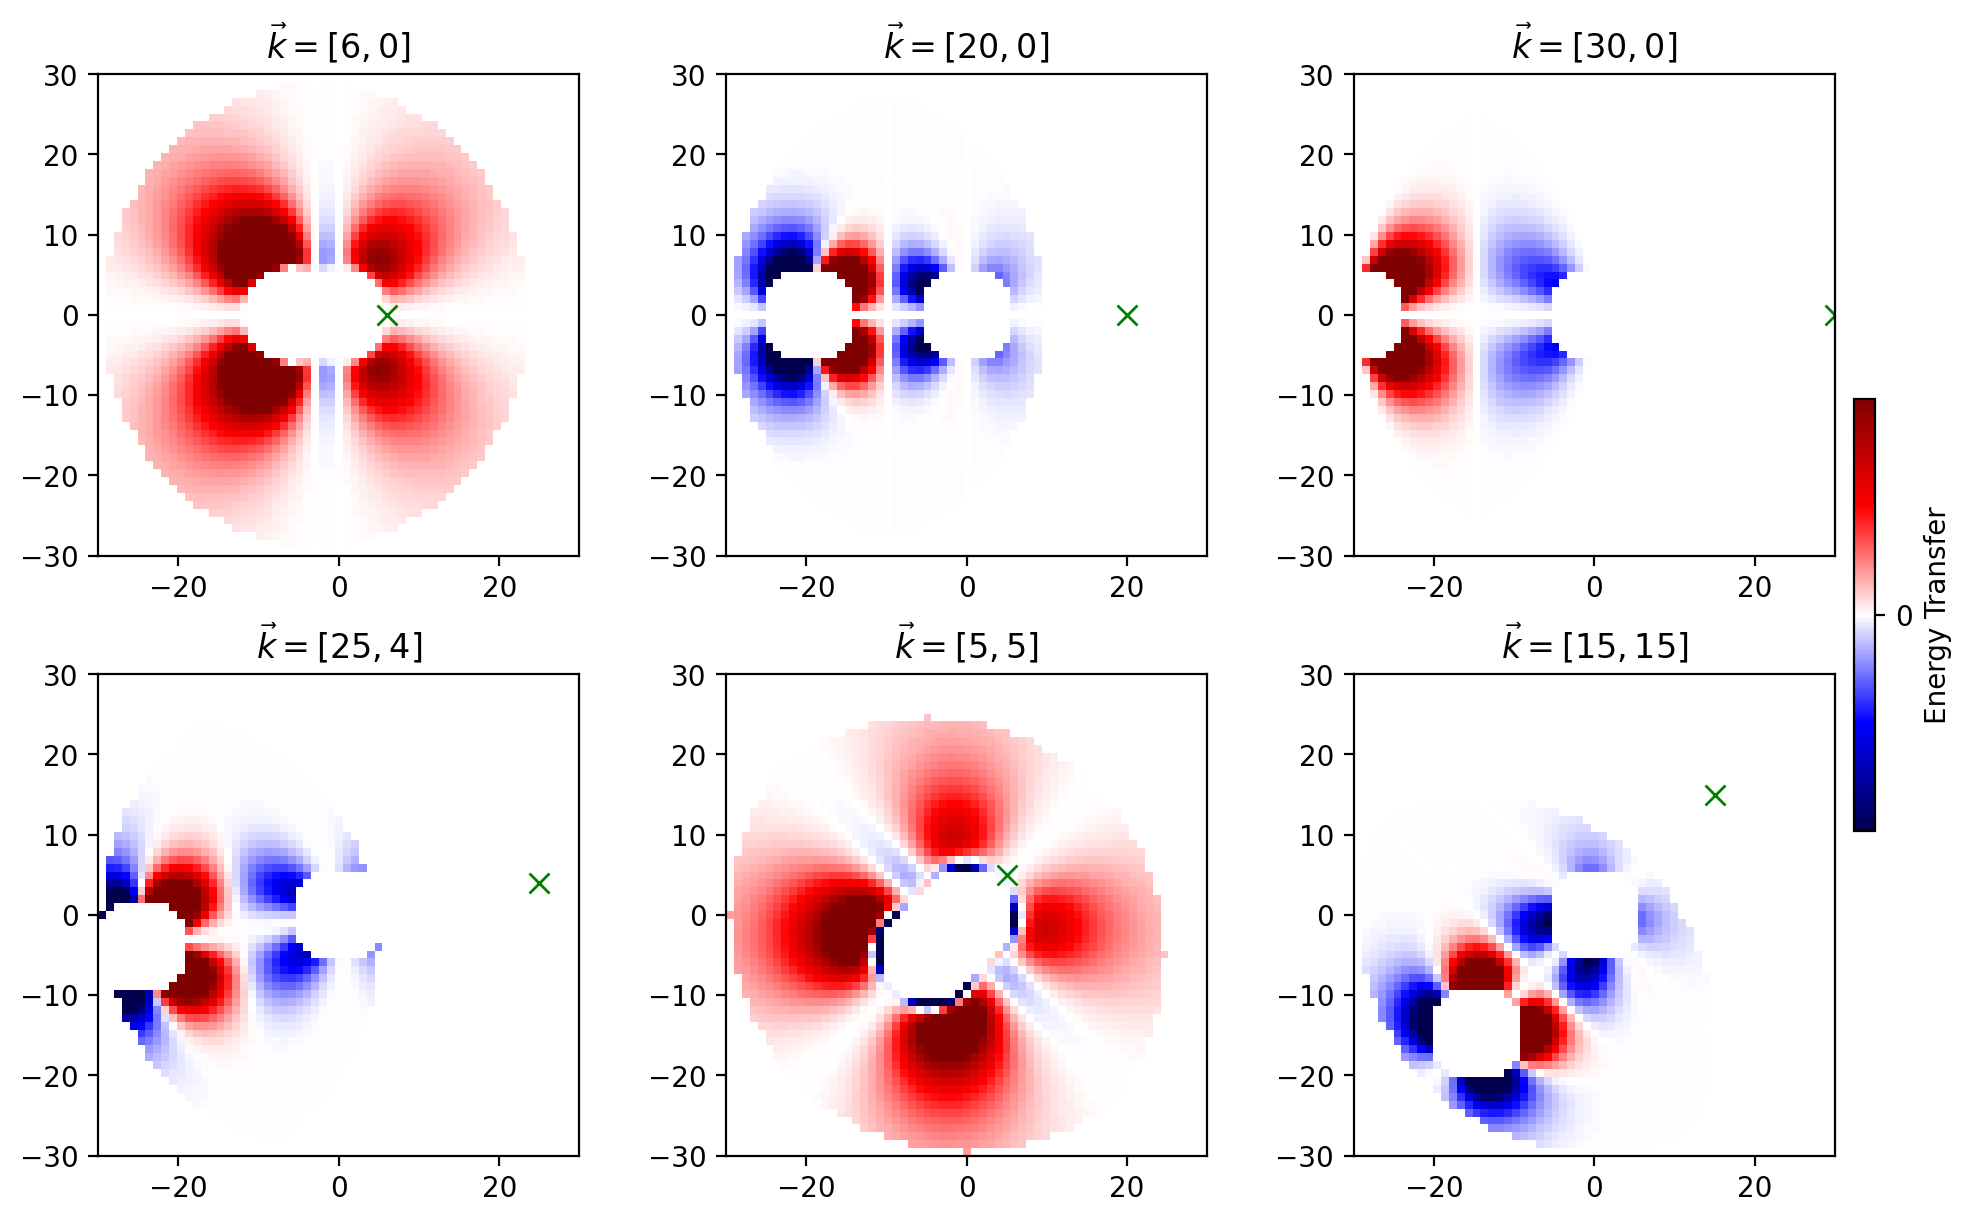

In [52]:
plot_G(Gcosrho_dir,small=False,cmap='seismic',colorbar=True,title='normal')

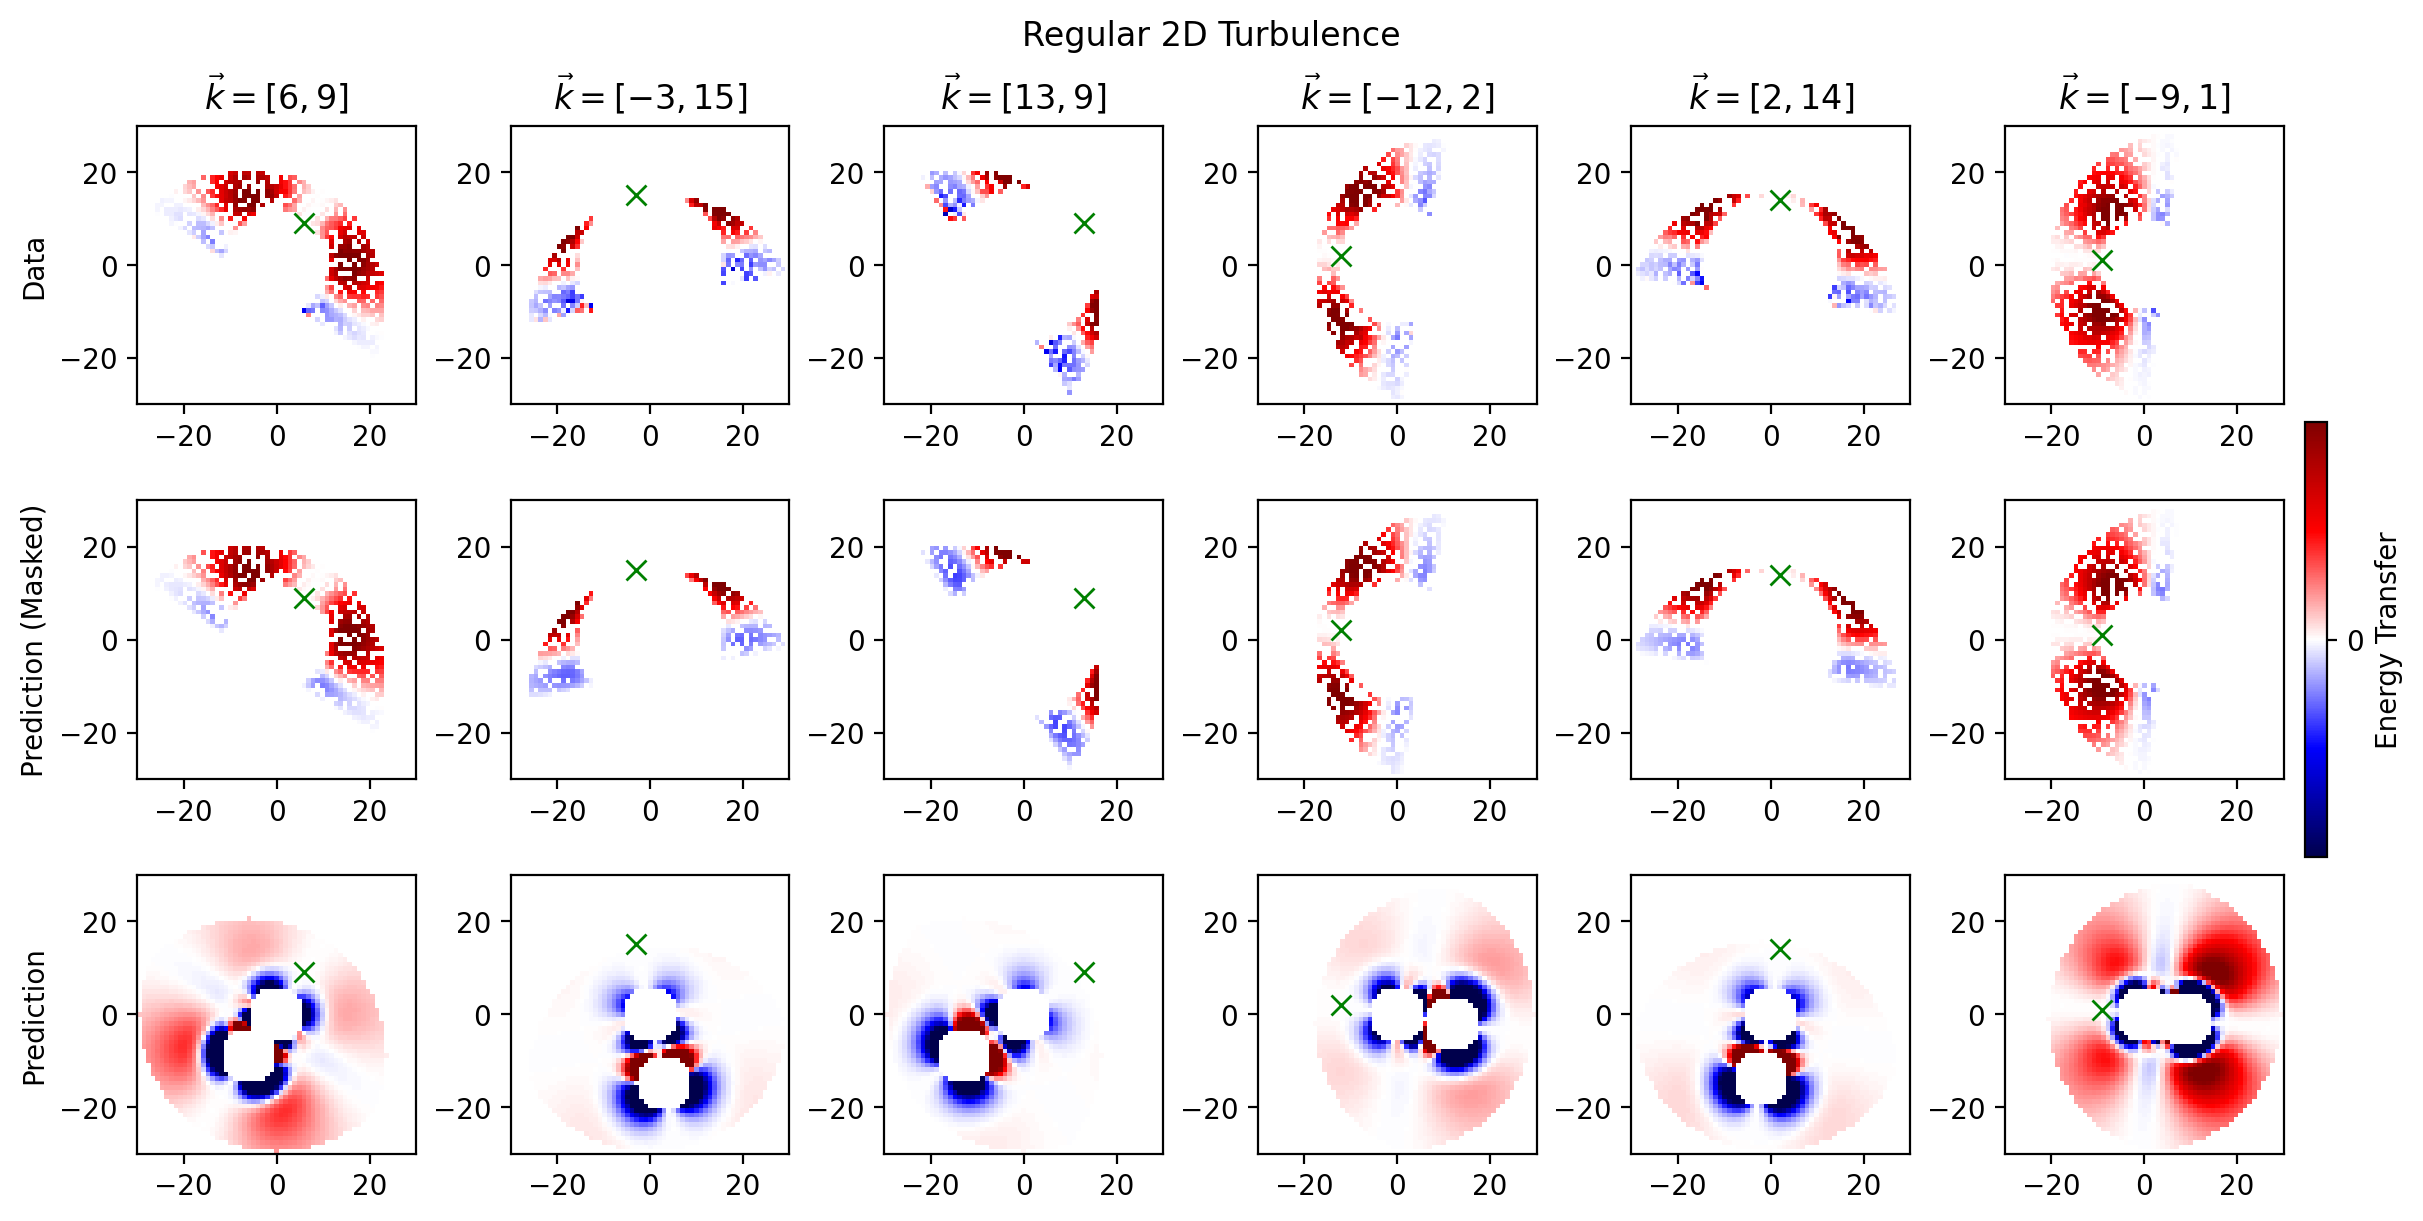

In [55]:
Gbin=np.zeros([len(idk.T)]*2)
Gbin[order(k_d),order(p_d)]=1

if path=='./data/regular_2D/':
    masked=Gcosrho_dir.copy();masked[Gcosrho_dir_data==0]=0
    points=idk[:,np.random.choice(np.argsort(Gbin.sum(axis=1))[::-1][:400],size=6,replace=False)].T
    # plot_G(Gcosrho_dir_data,points=points,title=r'Data')
    # plot_G(masked,points=points,title='Prediction (masked)')
    # plot_G(Gcosrho_dir,points=points,title='Prediction')
    plot_G_comparison(Gcosrho_dir_data,masked,Gcosrho_dir,points=points,title='Regular 2D Turbulence',cmap='seismic')
else:
    masked=Gcosrho_dir_con.copy();masked[Gcosrho_dir_data==0]=0
    points=idk[:,np.random.choice(np.argsort(Gbin.sum(axis=1))[::-1][:400],size=6,replace=False)].T # random points
    # minpoints=400
    # points=idk[:,(Gcosrho_dir_data!=0).sum(axis=1)>minpoints][:,np.argsort(np.linalg.norm(idk[:,(Gcosrho_dir_data!=0).sum(axis=1)>minpoints],axis=0))[::-1][:6]].T
    # plot_G(Gcosrho_dir_data,points=points,title=r'Data (mean $cos$ term)')
    # plot_G(masked,points=points,title='Prediction (masked)')
    # plot_G(Gcosrho_dir_con,points=points,title='Prediction')
    plot_G_comparison(Gcosrho_dir_data,masked,Gcosrho_dir_con,points=points,title='Condensate Turbulence',cmap='seismic')

[]

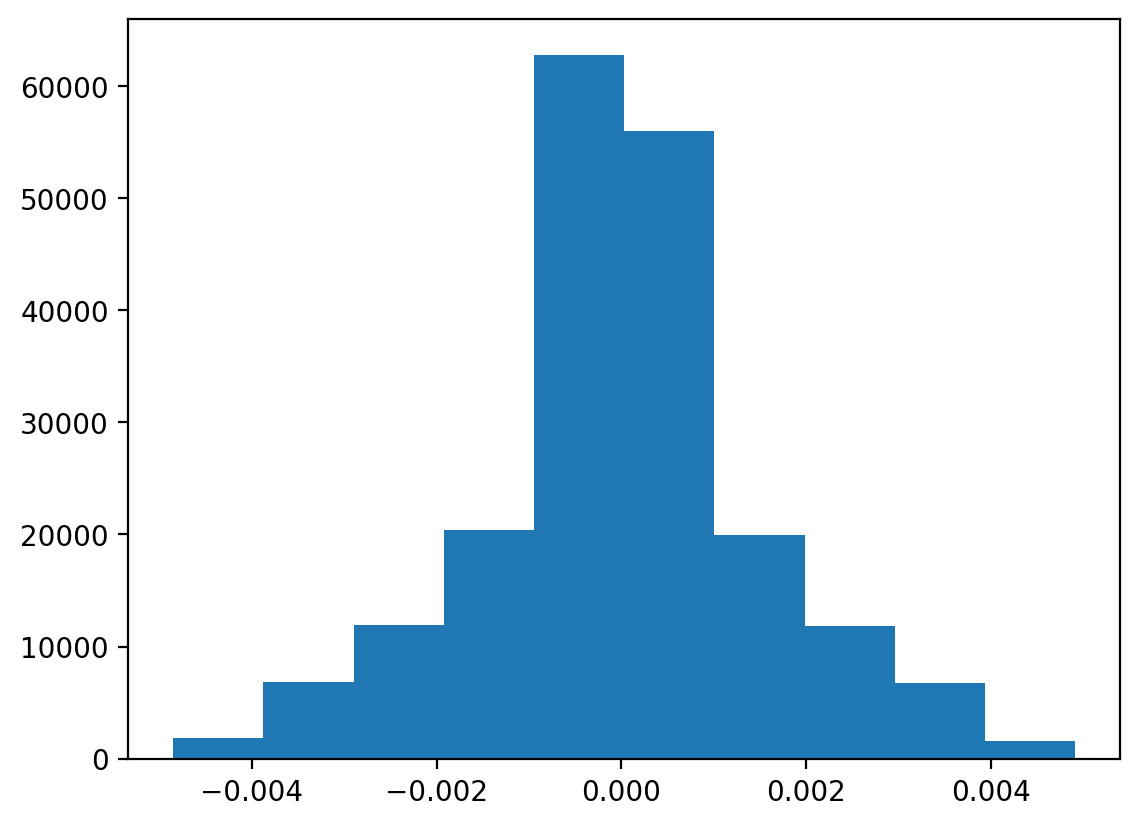

In [67]:
plt.hist(mean_sync);plt.plot()

[]

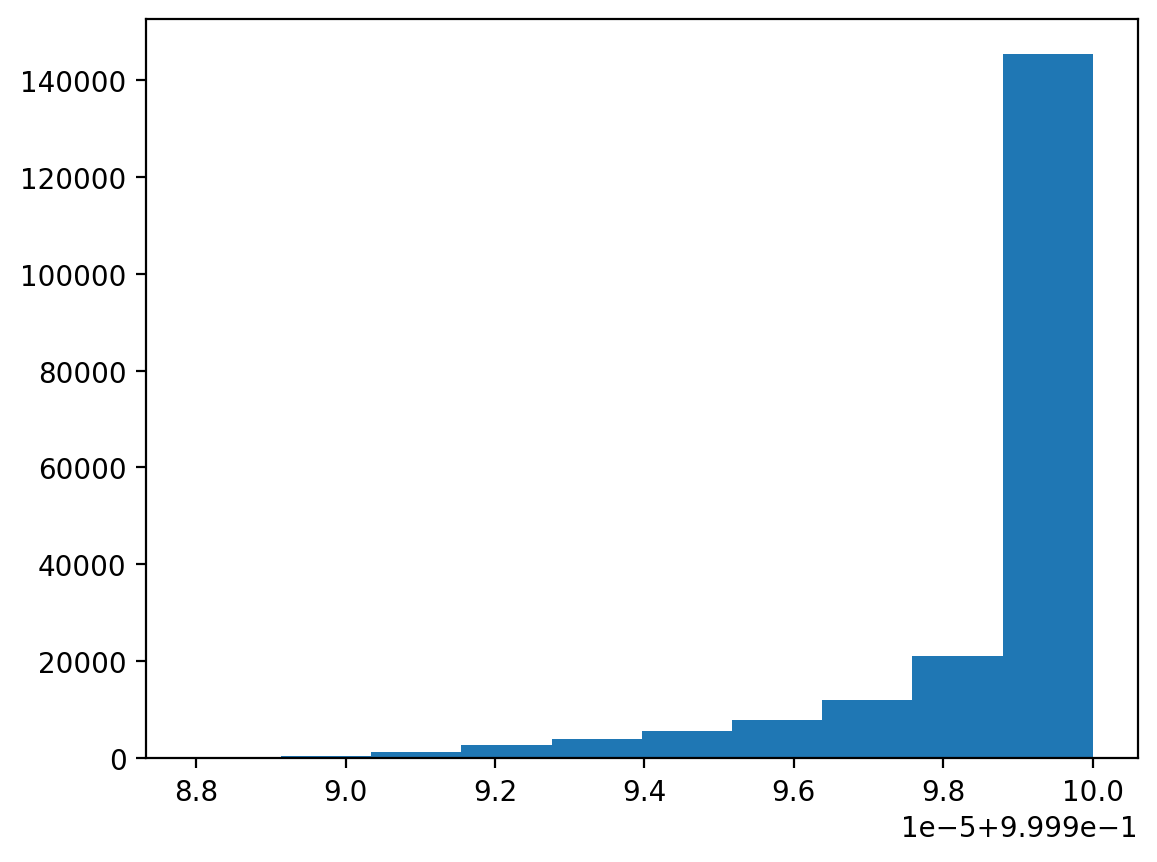

In [65]:
plt.hist(np.cos(mean_sync));plt.plot()

# Condensate $\rho$

In [20]:
path='./data/condensate/'

triads=np.loadtxt(path+'triads.txt')
rhok_data=np.load(path+'rhok.npy').astype(np.float64);rhop_data=np.load(path+'rhop.npy').astype(np.float64);rhoq_data=np.load(path+'rhoq.npy').astype(np.float64)
k_data=triads[:,[0,1]].T
p_data=triads[:,[2,3]].T
q_data=-k_data-p_data

k_d=np.column_stack((k_data,k_data,p_data,p_data,q_data,q_data))
p_d=np.column_stack((p_data,q_data,k_data,q_data,k_data,p_data))
q_d=np.column_stack((q_data,p_data,q_data,k_data,p_data,k_data))
# del k_data;del p_data;del q_data;del triads;
rhok_d=np.column_stack((rhok_data,rhok_data,rhop_data,rhop_data,rhoq_data,rhoq_data))[0]
rhop_d=np.column_stack((rhop_data,rhoq_data,rhok_data,rhoq_data,rhok_data,rhop_data))[0]
rhoq_d=np.column_stack((rhoq_data,rhop_data,rhoq_data,rhok_data,rhop_data,rhok_data))[0]
# del rhok_data;del rhop_data;del rhoq_data;
kmag_d=np.linalg.norm(k_d,axis=0);pmag_d=np.linalg.norm(p_d,axis=0);qmag_d=np.linalg.norm(q_d,axis=0)

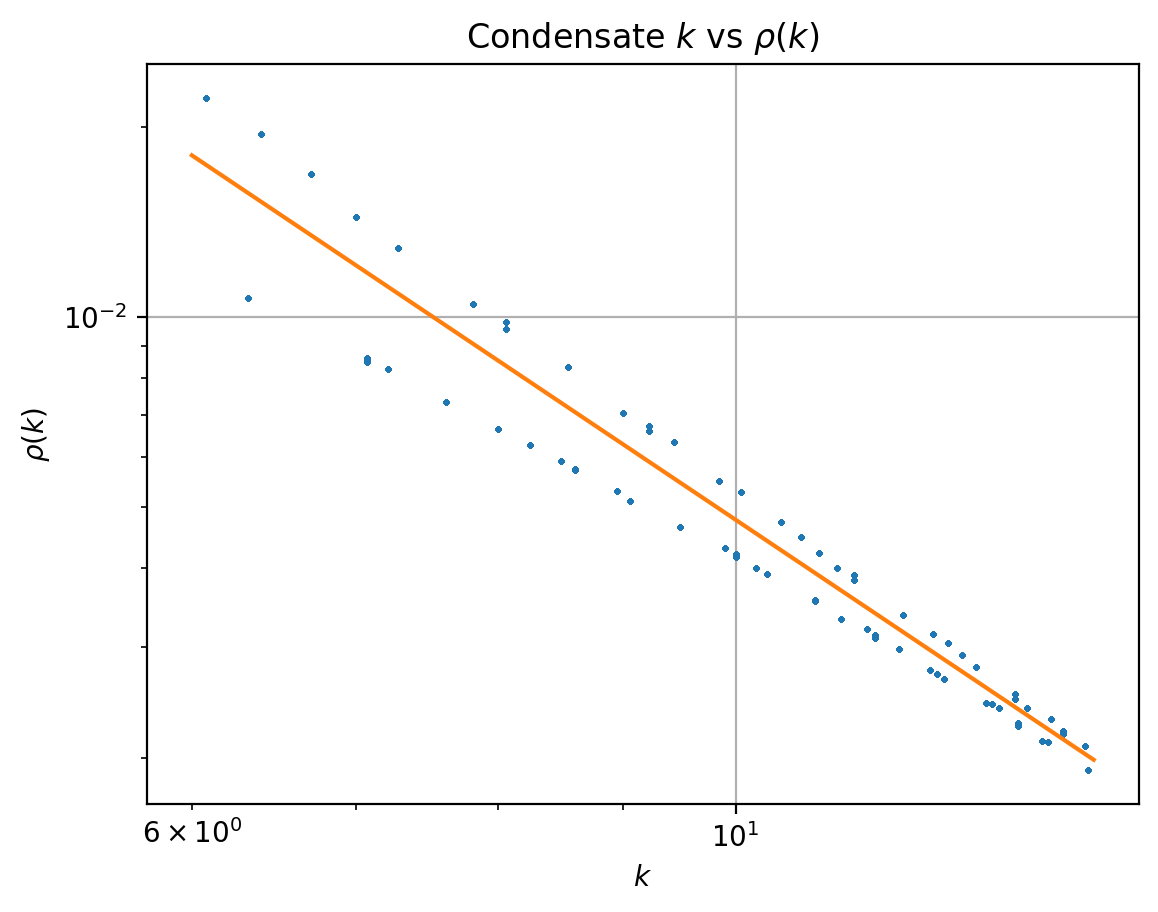

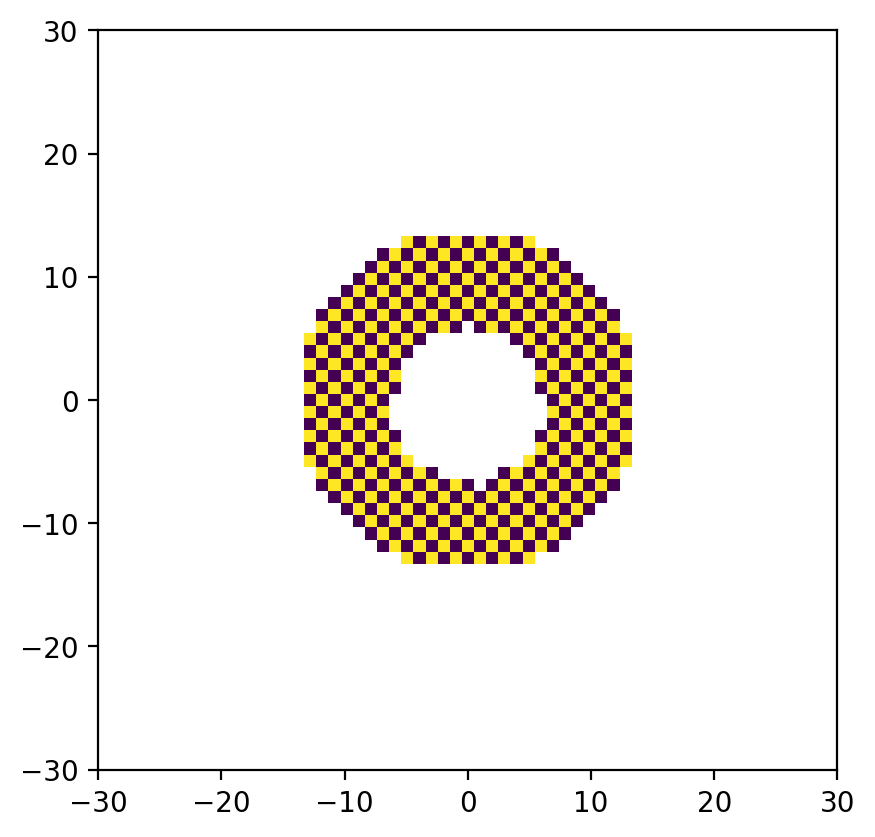

In [21]:
rhotest=lambda x: 0.85*x**(-7/3)
divide=lambda x: 1.9*x**-2.6
# plt.plot(np.linspace(6,30,100),rho_con(np.linspace(6,30,100)),label=r'$\rho(k)\propto k^{-3}$')
# plt.plot(np.linspace(6,30,100),rhotest(np.linspace(6,30,100)),label=r'$\rho(k)\propto k^{-7/3}$')
# plt.plot(np.linalg.norm(k_data,axis=0),rhok_data[0],'.',ms=2,label=r'data $\rho(k)$')
# plt.plot(np.linalg.norm(p_data,axis=0),rhop_data[0],'.',ms=2,label=r'data $\rho(p)$')
# plt.plot(np.linalg.norm(q_data,axis=0),rhoq_data[0],'.',ms=2,label=r'data $\rho(q)$')

mmax=14
plt.loglog(kmag_d[kmag_d<mmax],rhok_d[kmag_d<mmax],'.',ms=2)
plt.plot(np.linspace(6,mmax),divide(np.linspace(6,mmax)))
plt.xlabel(r'$k$')
plt.ylabel(r'$\rho(k)$')
plt.title(r'Condensate $k$ vs $\rho(k)$')
plt.grid()
# plt.legend()
plt.show()

mags=kmag_d[kmag_d<mmax]
ks=k_d[:,kmag_d<mmax]
rhos=rhok_d[kmag_d<mmax]
group1=rhos<divide(mags)
group2=rhos>divide(mags)

coords=(ks+kmax).astype(int)
grid=np.zeros([n]*2)
grid[coords[1,group1],coords[0,group1]]=1
grid[coords[1,group2],coords[0,group2]]=-1
grid[grid==0]=None
plt.imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower')
plt.show()

^ weird alternating for rho idk. at least there's a pattern to it. i'd assume this also holds for larger k but it's harder to divide those

In [23]:
print((order(ks[:,group1])%2).sum())
print((order(ks[:,group2])%2).sum())
print(group2.sum())

0
161506
161506


# Old Code

In [25]:
# path='./data/'
# triads=np.loadtxt(path+'triads.txt')
# k_data=triads[:,[0,1]].T
# p_data=triads[:,[2,3]].T
# q_data=-k_data-p_data

# k_order=order(k_data).argsort();p_order=order(p_data).argsort();q_order=order(q_data).argsort()
# k_data=k_data[:,k_order];p_data=p_data[:,p_order];q_data=q_data[:,q_order]

# kmag_data=np.linalg.norm(k_data,axis=0);pmag_data=np.linalg.norm(p_data,axis=0);qmag_data=np.linalg.norm(q_data,axis=0)

# rhok=np.load(path+'rhok.npy').astype(np.float64)[0,k_order];rhop=np.load(path+'rhop.npy').astype(np.float64)[0,p_order];rhoq=np.load(path+'rhoq.npy').astype(np.float64)[0,q_order]

# all_mag=np.array([kmag_data,pmag_data,qmag_data]).flatten()
# all_rho=np.array([rhok,rhop,rhoq]).flatten()

# # def rho(x,a,b):
# #     return a*(x**b)

# # a,b=curve_fit(rho,all_mag,all_rho)[0]
# # print(f'a = {a}, b = {b}')

# # rhok=rho(kmag,a,b)
# # rhop=rho(pmag,a,b)
# # rhoq=rho(qmag,a,b)

# # plt.plot(kmag,rho(kmag,a,b))
# # plt.plot(kmag_data,rhok,'.',ms=1)
# # plt.plot(pmag_data,rhop,'.',ms=1)
# # plt.plot(qmag_data,rhoq,'.',ms=1)
# # plt.show()

## Estimated $\cos$ term

In [27]:
# triads=np.loadtxt(path+'triads.txt')
# rhok_data=np.load(path+'rhok.npy').astype(np.float64);rhop_data=np.load(path+'rhop.npy').astype(np.float64);rhoq_data=np.load(path+'rhoq.npy').astype(np.float64)
# k_data=triads[:,[0,1]].T
# p_data=triads[:,[2,3]].T
# q_data=-k_data-p_data

# k_d=np.column_stack((k_data,k_data,p_data,p_data,q_data,q_data))
# p_d=np.column_stack((p_data,q_data,k_data,q_data,k_data,p_data))
# q_d=np.column_stack((q_data,p_data,q_data,k_data,p_data,k_data))
# del k_data;del p_data;del q_data;del triads;
# rhok_d=np.column_stack((rhok_data,rhok_data,rhop_data,rhop_data,rhoq_data,rhoq_data))[0]
# rhop_d=np.column_stack((rhop_data,rhoq_data,rhok_data,rhoq_data,rhok_data,rhop_data))[0]
# rhoq_d=np.column_stack((rhoq_data,rhop_data,rhoq_data,rhok_data,rhop_data,rhok_data))[0]
# del rhok_data;del rhop_data;del rhoq_data;
# kmag_d=np.linalg.norm(k_d,axis=0);pmag_d=np.linalg.norm(p_d,axis=0);qmag_d=np.linalg.norm(q_d,axis=0)

# K=((qmag_d**2-pmag_d**2)*kmag_d**-2*(rhop_d*rhoq_d)**2)+((pmag_d**2-kmag_d**2)*qmag_d**-2*(rhop_d*rhok_d)**2)+((kmag_d**2-qmag_d**2)*pmag_d**-2*(rhok_d*rhoq_d)**2)
# D=np.sqrt(pmag_d**2+qmag_d**2)
# C=-np.cross(q_d,p_d,axis=0)/(rhok_d*rhop_d*rhoq_d)*K
# dot_term=(k_d*p_d).sum(axis=0)
# rho_term=rhok_d*rhop_d*rhoq_d
# cos_term=-C/(2*D)
# gterm=pmag_d**2-qmag_d**2

# Gcosrho_dir_data=np.zeros([len(idk.T)]*2)
# Gcosrho_dir_data[order(k_d),order(p_d)]=np.cross(q_d,p_d,axis=0)*cos_term*rho_term*dot_term



# Gbin=np.zeros([len(idk.T)]*2)
# Gbin[order(k_d),order(p_d)]=1

# if path=='./data/regular_2D/':
#     masked=Gcosrho_dir.copy();masked[Gcosrho_dir_data==0]=0
#     points=idk[:,np.random.choice(np.argsort(Gbin.sum(axis=1))[::-1][:400],size=6,replace=False)].T
#     plot_G(Gcosrho_dir_data,points=points,title=r'Data (estimated $cos$ term)')
#     plot_G(masked,points=points,title='Prediction (masked)')
#     plot_G(Gcosrho_dir,points=points,title='Prediction')
# else:
#     masked=Gcosrho_dir_con.copy();masked[Gcosrho_dir_data==0]=0
#     points=idk[:,np.random.choice(np.argsort(Gbin.sum(axis=1))[::-1][:400],size=6,replace=False)].T
#     plot_G(Gcosrho_dir_data,points=points,title=r'Data (estimated $cos$ term)')
#     plot_G(masked,points=points,title='Prediction (masked)')
#     plot_G(Gcosrho_dir_con,points=points,title='Prediction')